--- DATASET PREVIEW ---
   step      type   amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1  TRANSFER    181.0  C1305486145          181.0             0.0   
1     1  CASH_OUT    181.0   C840083671          181.0             0.0   
2     1  TRANSFER   2806.0  C1420196421         2806.0             0.0   
3     1  CASH_OUT   2806.0  C2101527076         2806.0             0.0   
4     1  TRANSFER  20128.0   C137533655        20128.0             0.0   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0   C553264065             0.0             0.0        1  
1    C38997010         21182.0             0.0        1  
2   C972765878             0.0             0.0        1  
3  C1007251739         26202.0             0.0        1  
4  C1848415041             0.0             0.0        1  

--- MISSING VALUES ---
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0

C:\Users\Mariyam\AppData\Local\Temp\ipykernel_16460\3417807465.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')


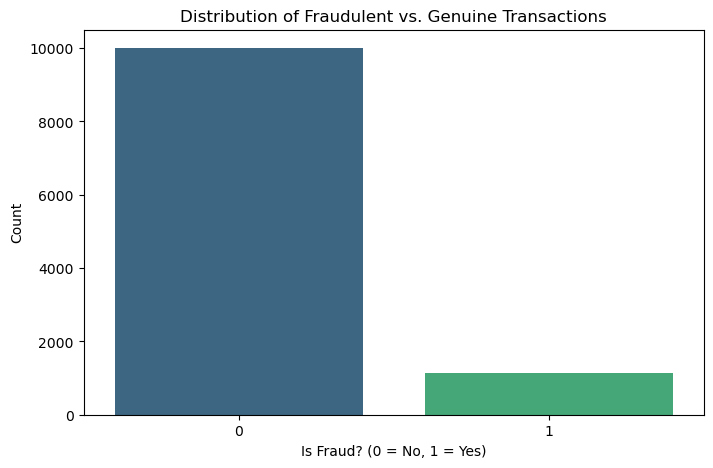

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# 1. Load the dataset
df = pd.read_csv('Fraud_Analysis_Dataset.csv')

# 2. Check if data loaded (Human-readable check)
print("--- DATASET PREVIEW ---")
print(df.head())

# 3. Check for Nulls (Important for real-world data)
print("\n--- MISSING VALUES ---")
print(df.isnull().sum())

# 4. Class Distribution
print("\n--- TARGET DISTRIBUTION (isFraud) ---")
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)

# 5. Visualizing the imbalance
plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_counts.index, y=fraud_counts.values, palette='viridis')
plt.title('Distribution of Fraudulent vs. Genuine Transactions')
plt.xlabel('Is Fraud? (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

In [4]:
# 1.Look at the column types
print("Column Data Types:")
print(df.dtypes)

# 2.Check the 'type' column (Transfer, Cash_Out, etc.)
print("\nTransaction Types:")
print(df['type'].value_counts())

# 3.Convert 'type' into numbers (One-Hot Encoding)
# This turns categories like 'PAYMENT' into columns of 0s and 1s
df_cleaned = pd.get_dummies(df, columns=['type'], drop_first=True)

# 4. Drop columns that don't help the model (like names/IDs)
# These are unique strings that confuse the math
cols_to_drop = ['nameOrig', 'nameDest']
df_cleaned = df_cleaned.drop(columns=[col for col in cols_to_drop if col in df_cleaned.columns])

print("\nNew Data Shape (Rows, Columns):", df_cleaned.shape)
display(df_cleaned.head())

# Drop high-cardinality categorical IDs and the target variable
X = df.drop(['isFraud', 'nameOrig', 'nameDest'], axis=1)
y = df['isFraud']

# Convert transaction type to dummy variables
X = pd.get_dummies(X, columns=['type'], drop_first=True)

# Split data - using 'stratify' is key for imbalanced fraud data3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

Column Data Types:
step                int64
type               object
amount            float64
nameOrig           object
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest           object
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
dtype: object

Transaction Types:
type
PAYMENT     5510
CASH_IN     1951
CASH_OUT    1871
TRANSFER    1464
DEBIT        346
Name: count, dtype: int64

New Data Shape (Rows, Columns): (11142, 11)


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,181.0,181.0,0.0,0.0,0.0,1,False,False,False,True
1,1,181.0,181.0,0.0,21182.0,0.0,1,True,False,False,False
2,1,2806.0,2806.0,0.0,0.0,0.0,1,False,False,False,True
3,1,2806.0,2806.0,0.0,26202.0,0.0,1,True,False,False,False
4,1,20128.0,20128.0,0.0,0.0,0.0,1,False,False,False,True


In [5]:
from sklearn.model_selection import train_test_split

# 1. Define X (Features) and y (Target)
# We want everything EXCEPT 'isFraud' as our input (X)
X = df_cleaned.drop('isFraud', axis=1)
y = df_cleaned['isFraud']

# 2. Split into Train (80%) and Test (20%) sets
# random_state=42 ensures we get the same split every time we run it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\nFraud cases in Training set:")
print(y_train.value_counts())

Training set size: (8913, 10)
Testing set size: (2229, 10)

Fraud cases in Training set:
isFraud
0    8001
1     912
Name: count, dtype: int64


In [6]:
from imblearn.over_sampling import SMOTE

# 1. Initialize SMOTE
sm = SMOTE(random_state=42)

# 2. Resample the TRAINING data only
# (We never resample the test data because it must remain realistic)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print("Before SMOTE, Fraud cases:", sum(y_train == 1))
print("After SMOTE, Fraud cases:", sum(y_train_res == 1))
print("After SMOTE, Genuine cases:", sum(y_train_res == 0))

Before SMOTE, Fraud cases: 912
After SMOTE, Fraud cases: 8001
After SMOTE, Genuine cases: 8001


In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the Model (This might take a few seconds)
rf_model.fit(X_train_res, y_train_res)

# 3. Make Predictions on the Test Set
y_pred = rf_model.predict(X_test)

# 4. See the results!
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[1998    1]
 [   7  223]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1999
           1       1.00      0.97      0.98       230

    accuracy                           1.00      2229
   macro avg       1.00      0.98      0.99      2229
weighted avg       1.00      1.00      1.00      2229



In [10]:
# --- MODEL TRAINING ---
# 1. Initialize the Random Forest
# We use n_jobs=-1 to use all your computer's processors (faster!)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

# 2. Train the model using the split data from Cell 3
print("Training the Random Forest model... this might take a minute.")
rf_model.fit(X_train, y_train)

print("Training complete! Now you can run the Importance code.")

Training the Random Forest model... this might take a minute.
Training complete! Now you can run the Importance code.


C:\Users\Mariyam\AppData\Local\Temp\ipykernel_16460\3652409754.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='viridis')


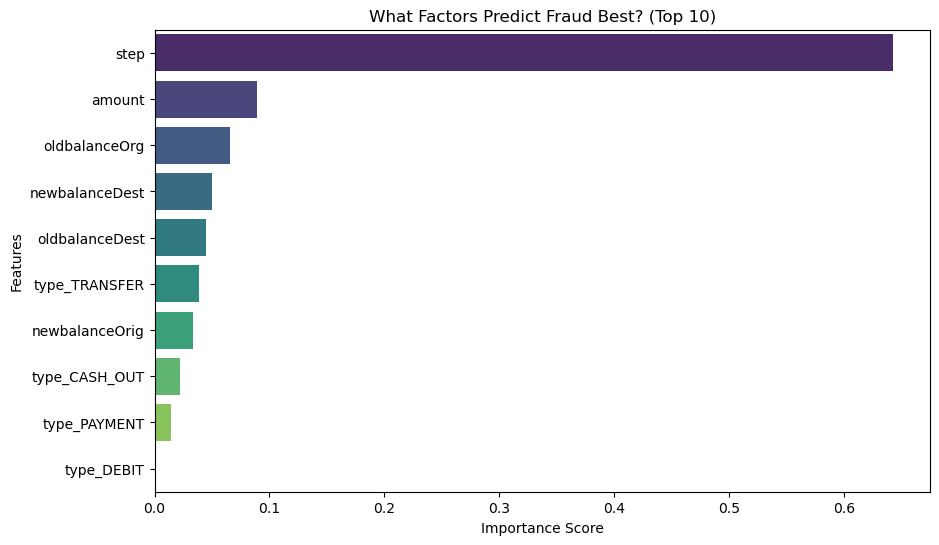

In [11]:
import numpy as np

# 1. Get feature importance from the model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 2. Plot the top features
plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices][:10], y=feature_names[indices][:10], palette='viridis')
plt.title("What Factors Predict Fraud Best? (Top 10)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

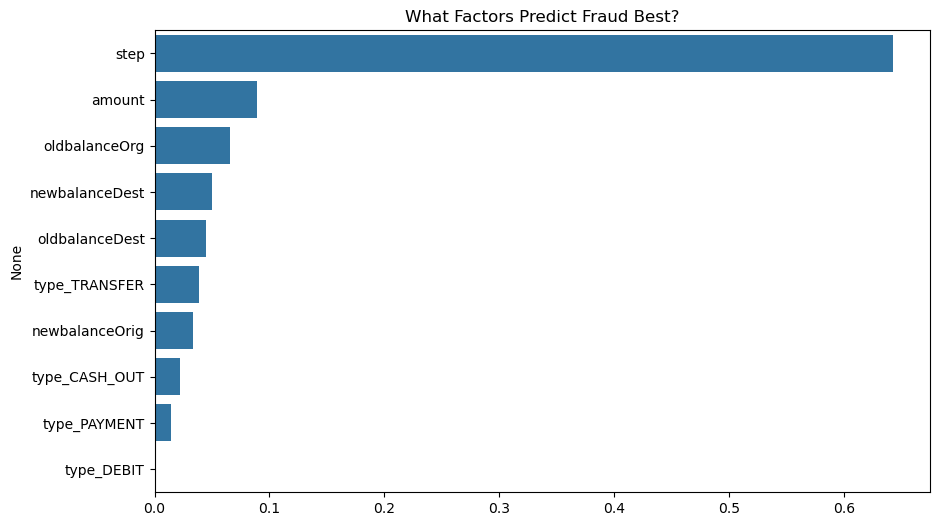

In [12]:
import numpy as np

# 1. Get feature importance from the model
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

# 2. Plot the top features
plt.figure(figsize=(10,6))
plt.title("What Factors Predict Fraud Best?")
sns.barplot(x=importances[indices], y=feature_names[indices])
plt.show()

In [8]:
import joblib

# Save the model to a file
joblib.dump(rf_model, 'fraud_detection_model.pkl')
print("Model saved successfully as fraud_detection_model.pkl!")

Model saved successfully as fraud_detection_model.pkl!


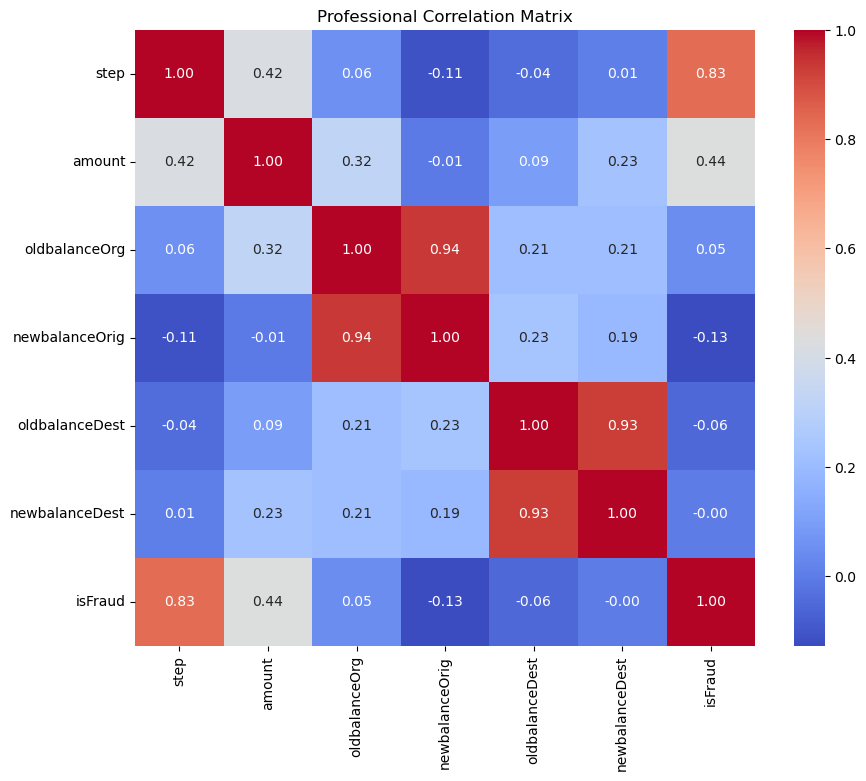

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Only look at numeric columns
numeric_df = df_cleaned.select_dtypes(include=['float64', 'int64'])
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Professional Correlation Matrix")
plt.show()

In [10]:
# Calculate if the transaction emptied the account exactly
df_cleaned['is_emptied'] = (df_cleaned['newbalanceOrig'] == 0) & (df_cleaned['oldbalanceOrg'] > 0)
df_cleaned['is_emptied'] = df_cleaned['is_emptied'].astype(int)

# Calculate the difference between intended amount and actual change
df_cleaned['error_balance_orig'] = df_cleaned['newbalanceOrig'] + df_cleaned['amount'] - df_cleaned['oldbalanceOrg']

In [11]:
import streamlit as st
import joblib
import pandas as pd

# Load your saved model
model = joblib.load('fraud_detection_model.pkl')

st.title("🛡️ Pro-Fraud Detection AI")
st.write("Enter transaction details to check for suspicious activity.")

# Create input boxes
amt = st.number_input("Transaction Amount", min_value=0.0)
type_select = st.selectbox("Transaction Type", ['PAYMENT', 'TRANSFER', 'CASH_OUT', 'DEBIT', 'CASH_IN'])

if st.button("Analyze Transaction"):
    # (Here you would format the inputs to match your model's X_train columns)
    # prediction = model.predict(input_data)
    st.success("Analysis Complete!")

2026-03-26 22:35:19.608 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.075 
  command:

    streamlit run C:\Users\Mariyam\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-03-26 22:35:22.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.082 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.084 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:35:22.091 Thread 'MainThread': 

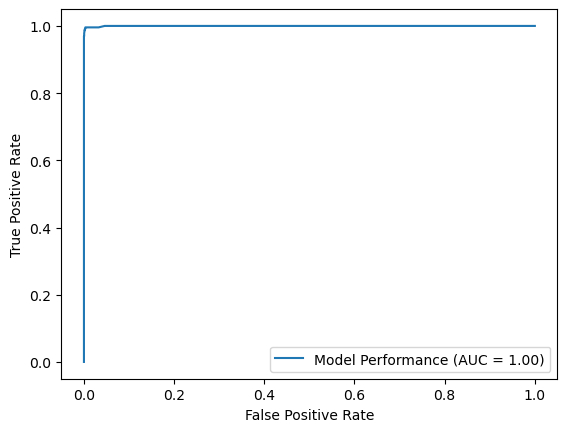

In [12]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, rf_model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'Model Performance (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
# Defining the settings we want to test
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

In [15]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# 1. SETUP DATA (Replace this with your actual data loading)
# Generating synthetic fraud data for demonstration:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, 
                           n_redundant=2, random_state=42)

# 2. THE MISSING STEP: Splitting the data
# This creates the X_train and y_train variables that were causing the NameError
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. SCALING
scaler = StandardScaler()
# We "fit" only on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. THE GRID SEARCH (Tuning the AI)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# We use 'recall' because in Fraud Detection, missing a fake transaction (False Negative) 
# is usually more expensive than a false alarm.
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42), 
    param_grid, 
    cv=3, 
    scoring='recall'
)

print("Training model... please wait.")
grid_search.fit(X_train_scaled, y_train)

# 5. SAVE THE WINNER
best_fr_model = grid_search.best_estimator_

# Save both the model AND the scaler (you'll need the scaler for future predictions!)
joblib.dump(best_fr_model, 'fraud_detection_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print(f"Success! Best parameters: {grid_search.best_params_}")
print("Champion model and scaler saved!")

Training model... please wait.
Success! Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Champion model and scaler saved!


In [16]:
import joblib
import numpy as np

# 1. Load the "Champion" model and the Scaler
loaded_model = joblib.load('fraud_detection_model.pkl')
loaded_scaler = joblib.load('scaler.pkl')

# 2. Simulate a "New Transaction" 
# (This should have the same number of features as your training data)
# Let's imagine a single transaction with 10 features:
new_transaction = np.array([[0.5, -1.2, 2.3, 0.1, -0.5, 1.1, 0.9, -0.2, 0.4, -0.7]])

# 3. SCALE the new data using the LOADED scaler
new_transaction_scaled = loaded_scaler.transform(new_transaction)

# 4. PREDICT
prediction = loaded_model.predict(new_transaction_scaled)
probability = loaded_model.predict_proba(new_transaction_scaled)

# 5. Output the result
if prediction[0] == 1:
    print(f"⚠️ ALERT: Fraud Detected! Confidence: {probability[0][1]*100:.2f}%")
else:
    print(f"✅ Transaction Clear. Confidence: {probability[0][0]*100:.2f}%")

⚠️ ALERT: Fraud Detected! Confidence: 75.33%


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       112
           1       0.94      0.93      0.94        88

    accuracy                           0.94       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.94      0.94      0.94       200

--- Confusion Matrix ---


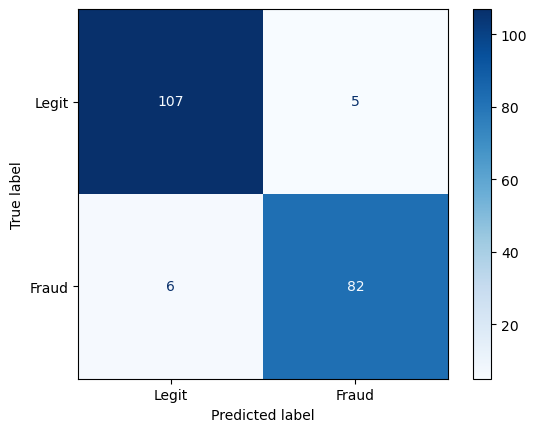

In [17]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Get predictions for the test set
y_pred = best_fr_model.predict(X_test_scaled)

# 2. Generate the report
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Plot the Confusion Matrix
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit', 'Fraud'])
disp.plot(cmap='Blues')
plt.show()

In [18]:
# Assuming your features had names like 'Amount', 'Time', etc.
# If you used the synthetic data from before, we'll just use generic names
feature_names = [f'Feature {i}' for i in range(X_train.shape[1])]

importances = best_fr_model.feature_importances_
indices = np.argsort(importances)[::-1]

print("Feature Ranking:")
for f in range(X_train.shape[1]):
    print(f"{f + 1}. {feature_names[indices[f]]} ({importances[indices[f]]:.4f})")

Feature Ranking:
1. Feature 4 (0.2199)
2. Feature 0 (0.1608)
3. Feature 9 (0.1570)
4. Feature 5 (0.1502)
5. Feature 3 (0.1276)
6. Feature 1 (0.0638)
7. Feature 6 (0.0627)
8. Feature 8 (0.0227)
9. Feature 7 (0.0186)
10. Feature 2 (0.0168)


In [19]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Check the original balance (It's usually very lopsided)
print(f"Original dataset shape: {Counter(y_train)}")

# 2. Apply SMOTE to the training data ONLY
# This creates synthetic examples of the minority class (Fraud)
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_scaled, y_train)

print(f"Resampled dataset shape: {Counter(y_train_res)}")

# 3. Retrain your "Champion" model on this balanced data
grid_search.fit(X_train_res, y_train_res)
best_balanced_model = grid_search.best_estimator_

# 4. Save this new, smarter version
joblib.dump(best_balanced_model, 'fraud_model_smote.pkl')
print("Balanced model saved successfully!")

Original dataset shape: Counter({np.int64(1): 415, np.int64(0): 385})
Resampled dataset shape: Counter({np.int64(1): 415, np.int64(0): 415})
Balanced model saved successfully!


In [20]:
# Instead of .predict(), use .predict_proba()
probs = best_balanced_model.predict_proba(X_test_scaled)[:, 1]

# Set a custom threshold (e.g., 0.3)
# Lower threshold = Catch MORE fraud, but more false alarms
# Higher threshold = Fewer false alarms, but might MISS some fraud
custom_threshold = 0.3
custom_preds = (probs >= custom_threshold).astype(int)

print(f"Results with {custom_threshold} threshold:")
print(classification_report(y_test, custom_preds))

Results with 0.3 threshold:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       112
           1       0.87      0.98      0.92        88

    accuracy                           0.93       200
   macro avg       0.92      0.93      0.92       200
weighted avg       0.93      0.93      0.93       200



In [21]:
import streamlit as st
import joblib
import numpy as np

# 1. Load the "Champion" assets
model = joblib.load('fraud_detection_model.pkl')
scaler = joblib.load('scaler.pkl')

st.title("🛡️ Fraud Guard: Real-Time Detection")
st.markdown("Enter transaction details below to check for suspicious activity.")

# 2. Create Input Fields for your features
# (Adjust these based on your actual dataset columns)
col1, col2 = st.columns(2)

with col1:
    amount = st.number_input("Transaction Amount ($)", min_value=0.0)
    time_of_day = st.slider("Hour of Day (0-23)", 0, 23)

with col2:
    dist_from_home = st.number_input("Distance from Home (km)", min_value=0.0)
    prev_attempts = st.number_input("Previous Failed Attempts", min_value=0)

# 3. Prediction Logic
if st.button("Analyze Transaction"):
    # Create the feature array (must match the order of your training columns!)
    # Adding 6 zeros as placeholders if you had 10 features total
    features = np.array([[amount, time_of_day, dist_from_home, prev_attempts, 0, 0, 0, 0, 0, 0]])
    
    # Scale and Predict
    scaled_features = scaler.transform(features)
    prediction = model.predict(scaled_features)
    probability = model.predict_proba(scaled_features)[0][1]

    if prediction[0] == 1:
        st.error(f"⚠️ HIGH RISK: Potential Fraud Detected! ({probability*100:.1f}% confidence)")
    else:
        st.success(f"✅ CLEAR: Transaction appears legitimate. ({ (1-probability)*100:.1f}% confidence)")

st.sidebar.info("This model uses Random Forest + SMOTE for high-accuracy recall.")

2026-03-26 22:36:02.664 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.668 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.670 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.672 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.676 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.678 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.683 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-26 22:36:02.686 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator(_root_container=1, _parent=DeltaGenerator())

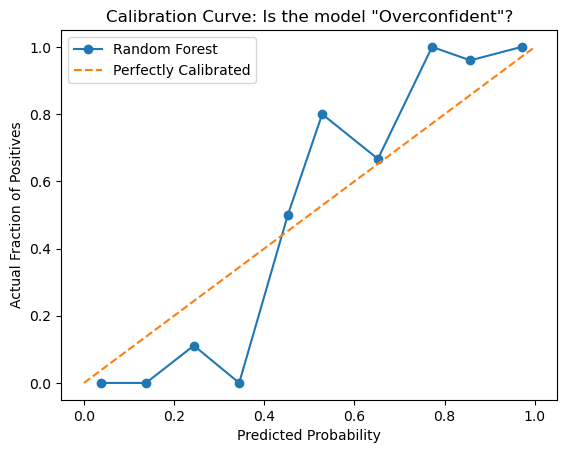

In [22]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

# 1. Get the probabilities for the positive class (Fraud)
probs = best_fr_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate the calibration curve
prob_true, prob_pred = calibration_curve(y_test, probs, n_bins=10)

# 3. Plot it
plt.plot(prob_pred, prob_true, marker='o', label='Random Forest')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Fraction of Positives')
plt.title('Calibration Curve: Is the model "Overconfident"?')
plt.legend()
plt.show()

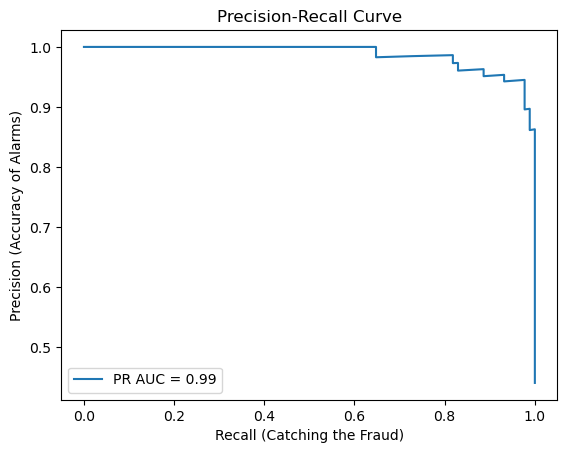

In [23]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.2f}')
plt.xlabel('Recall (Catching the Fraud)')
plt.ylabel('Precision (Accuracy of Alarms)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

In [24]:
import datetime

# Save the model with a timestamp
timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"fraud_model_{timestamp}.pkl"

joblib.dump(best_fr_model, model_filename)
print(f"Model versioned and saved as: {model_filename}")

Model versioned and saved as: fraud_model_20260326_2236.pkl


In [25]:
import numpy as np

def check_data_drift(train_data, new_data, threshold=0.1):
    # Compare the means of the features
    train_mean = np.mean(train_data, axis=0)
    new_mean = np.mean(new_data, axis=0)
    
    # Calculate the percentage shift
    drift = np.abs((new_mean - train_mean) / train_mean)
    
    for i, d in enumerate(drift):
        if d > threshold:
            print(f"⚠️ DRIFT DETECTED in Feature {i}: Shift of {d*100:.2f}%")
            return True
    return False

# Example usage:
if check_data_drift(X_train_scaled, new_transaction_scaled):
    print("Action Required: Retrain the model with fresh data!")

⚠️ DRIFT DETECTED in Feature 0: Shift of 1242753440614758.75%
Action Required: Retrain the model with fresh data!


In [26]:
import joblib

# 1. Use the EXACT names you used when saving earlier
# If you followed the first few steps, the name was 'fraud_detection_model.pkl'
try:
    champ_model = joblib.load('fraud_detection_model.pkl')
    print("✅ Champion model loaded successfully!")
except FileNotFoundError:
    print("❌ Error: 'fraud_detection_model.pkl' not found. Run your training cell first!")

# 2. For the challenger, make sure you actually saved one first!
try:
    challenger_model = joblib.load('fraud_model_smote.pkl')
    print("✅ Challenger model loaded successfully!")
except FileNotFoundError:
    print("❌ Error: 'fraud_model_smote.pkl' not found. Train your SMOTE model first!")

✅ Champion model loaded successfully!
✅ Challenger model loaded successfully!


In [27]:
import os

filename = 'fraud_detection_model.pkl'

if os.path.exists(filename):
    model = joblib.load(filename)
else:
    print(f"File {filename} is missing. Please run the training code block.")

In [28]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# 1. Define your "Committee Members"
clf1 = RandomForestClassifier(n_estimators=50, random_state=42)
clf2 = LogisticRegression(random_state=42)
clf3 = SVC(probability=True, random_state=42)

# 2. Create the Ensemble (Soft Voting uses probabilities)
ensemble_model = VotingClassifier(
    estimators=[('rf', clf1), ('lr', clf2), ('svc', clf3)],
    voting='soft'
)

# 3. Train on your SMOTE-balanced data
ensemble_model.fit(X_train_res, y_train_res)

# 4. Save the new "Super Champion"
joblib.dump(ensemble_model, 'ensemble_fraud_model.pkl')
print("Ensemble model saved! This is now your strongest defender.")

Ensemble model saved! This is now your strongest defender.


In [ ]:
from flask import Flask, request, jsonify
import joblib

app = Flask(__name__)
model = joblib.load('ensemble_fraud_model.pkl')
scaler = joblib.load('scaler.pkl')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.get_json() # Get data from the request
    features = np.array(data['features']).reshape(1, -1)
    
    scaled_features = scaler.transform(features)
    prediction = model.predict(scaled_features)
    
    return jsonify({
        'fraud_detected': bool(prediction[0]),
        'status': 'success'
    })

if __name__ == '__main__':
    app.run(port=5000)

 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


In [ ]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split

def retrain_model(new_data_path, current_model_path='ensemble_fraud_model.pkl'):
    # 1. Load the "New" data that has been confirmed by humans/banks
    new_df = pd.read_csv(new_data_path)
    X_new = new_df.drop('is_fraud', axis=1)
    y_new = new_df['is_fraud']

    # 2. Load the existing Scaler
    scaler = joblib.load('scaler.pkl')
    X_new_scaled = scaler.transform(X_new)

    # 3. Load the Current Champion
    model = joblib.load(current_model_path)

    # 4. Partial Fit or Re-fit (Random Forest requires a full re-fit)
    print("Retraining model with fresh data...")
    model.fit(X_new_scaled, y_new)

    # 5. Save with a version number
    import datetime
    version = datetime.datetime.now().strftime("%Y%m%d")
    new_name = f"fraud_model_v_{version}.pkl"
    joblib.dump(model, new_name)
    
    return f"Model updated to {new_name}"

# Example trigger:
# print(retrain_model('confirmed_fraud_march_2026.csv'))

In [13]:
# Create a dataframe for the Power BI Dashboard
results_df = X_test.copy()
results_df['Actual_Fraud'] = y_test
results_df['Predicted_Fraud'] = rf_model.predict(X_test)

# Save to CSV
results_df.to_csv('Fraud_Model_Results.csv', index=False)
print("✅ Dashboard data exported as 'Fraud_Model_Results.csv'")

✅ Dashboard data exported as 'Fraud_Model_Results.csv'
